## Load the dataset

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\maigi\Downloads\Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Check the dataset

In [2]:
print(df.shape)

(2200, 8)


In [3]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB
None


In [4]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


## Check the crop labels

In [6]:
print(df["label"].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


## Split Features and Target

In [7]:
X = df.drop("label", axis=1)
y = df["label"]

## Encode the Labels

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

## Split the Dataset

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Define Models

In [11]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Support Vector Machine":
        SVC(),

    "XGBoost":
        XGBClassifier(
            eval_metric="mlogloss",
            random_state=42
        )
}

## Train and Compare

In [12]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision":
            precision_score(
                y_test,
                pred,
                average="weighted"
            ),

        "Recall":
            recall_score(
                y_test,
                pred,
                average="weighted"
            ),

        "F1 Score":
            f1_score(
                y_test,
                pred,
                average="weighted"
            )
    })

C:\Users\maigi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Display Results

In [13]:
results = pd.DataFrame(results)

results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

print(results)

                    Model  Accuracy  Precision    Recall  F1 Score
2           Random Forest  0.995455   0.995671  0.995455  0.995452
4                 XGBoost  0.990909   0.991539  0.990909  0.990834
3  Support Vector Machine  0.984091   0.986580  0.984091  0.983908
1           Decision Tree  0.979545   0.980598  0.979545  0.979423
0     Logistic Regression  0.950000   0.951955  0.950000  0.949971


In [20]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Confusion Matrix

<Figure size 1200x1200 with 0 Axes>

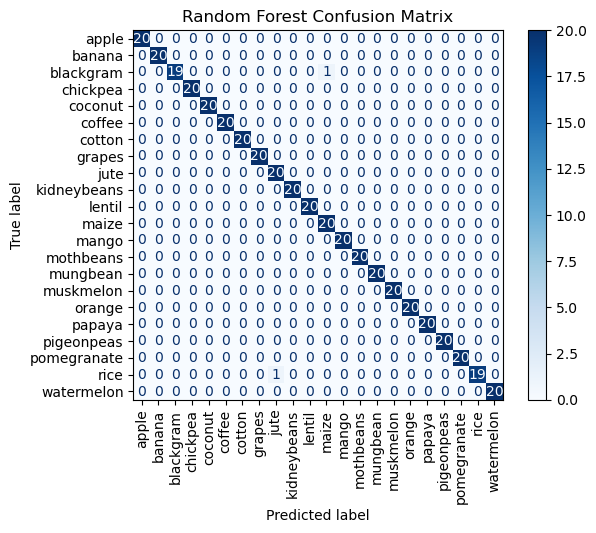

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction using the best model
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Plot Accuracy Comparison

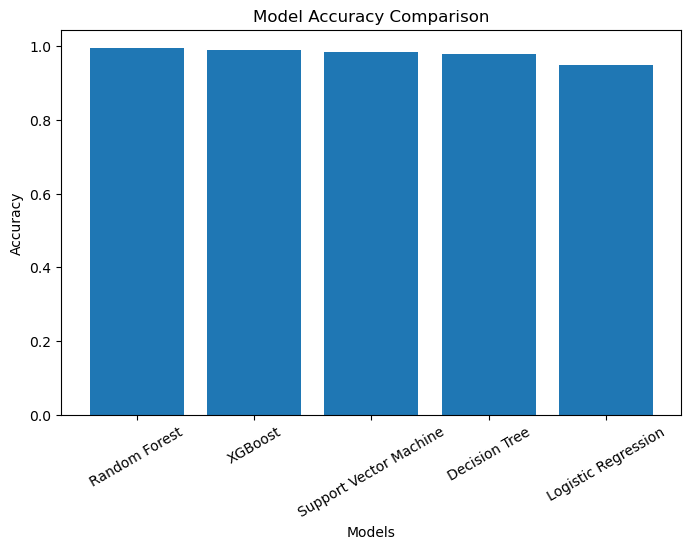

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

## Plot Precision, Recall and F1-Score

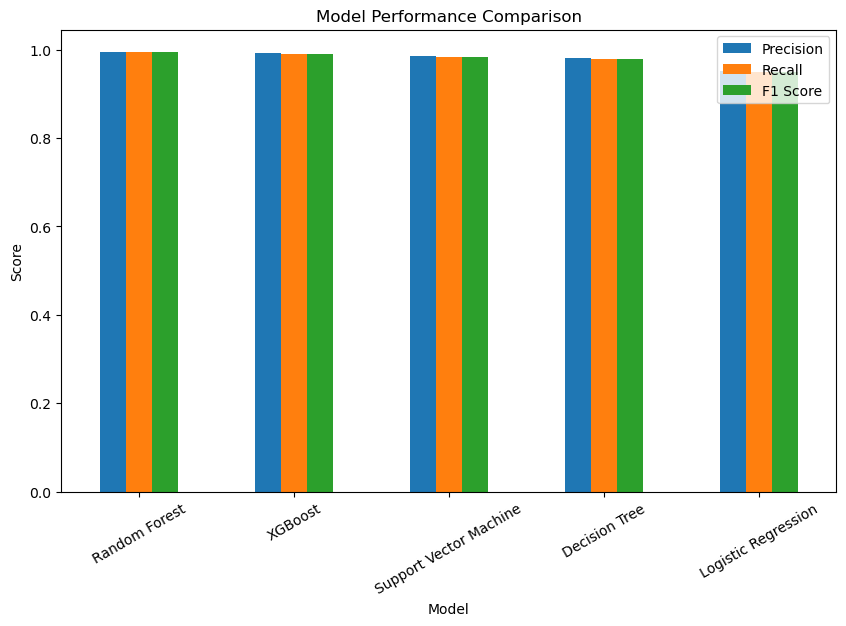

In [23]:
metrics = ["Precision", "Recall", "F1 Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=30)

plt.show()

## Confusion Matrix (Best Model Only)

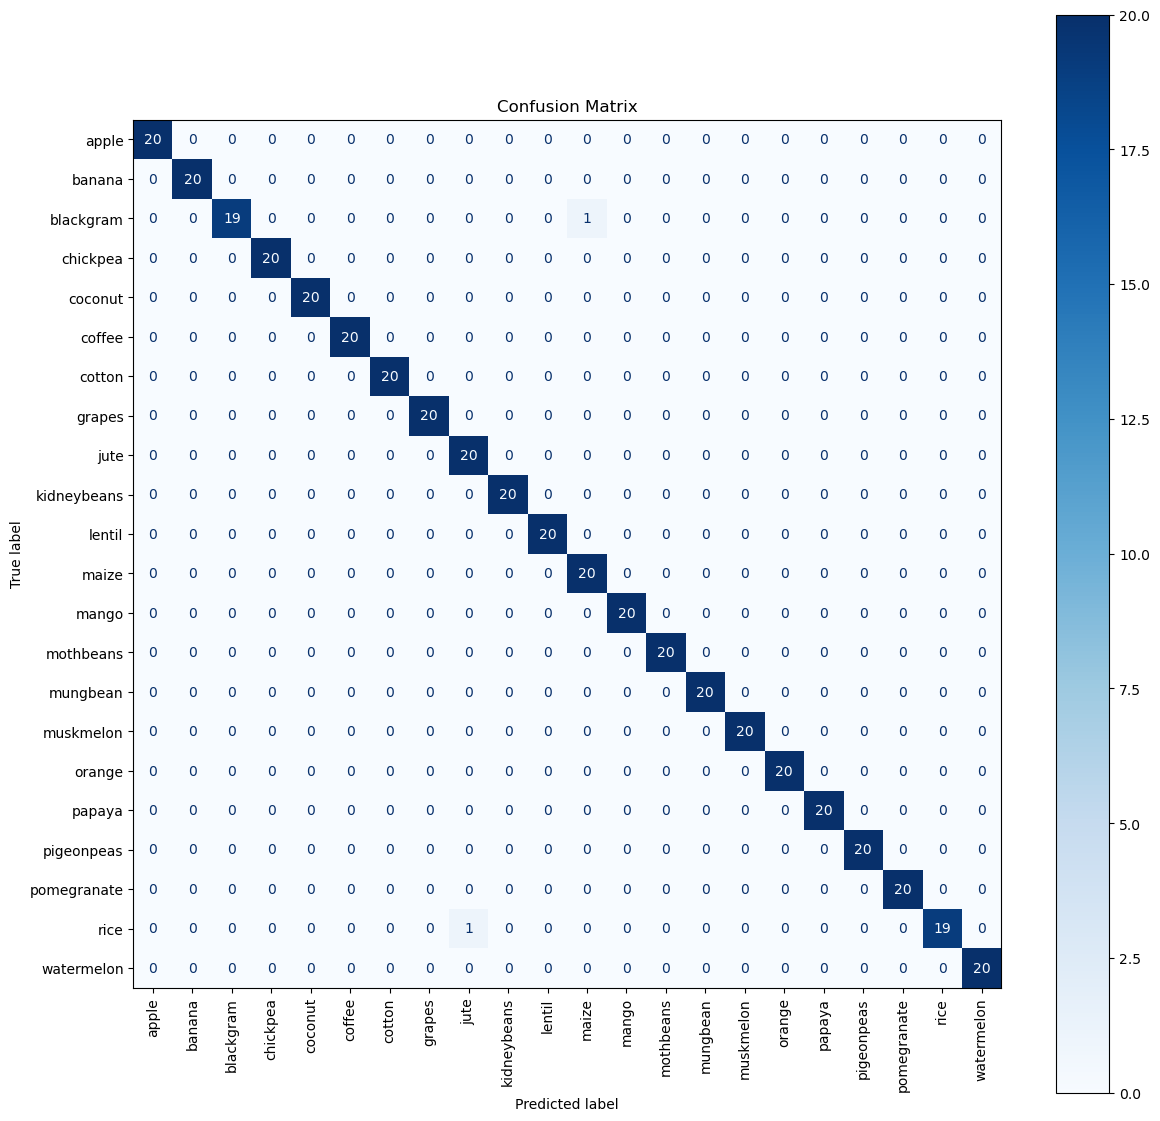

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(14,14))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

## Classification Report

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

## Feature Importance

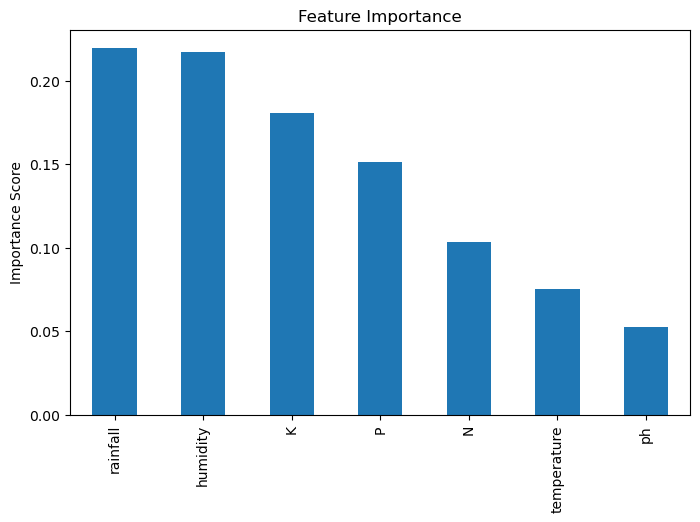

rainfall       0.219641
humidity       0.217058
K              0.180813
P              0.151342
N              0.103356
temperature    0.075485
ph             0.052305
dtype: float64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

print(importance)

## Save the Model

In [27]:
import joblib

joblib.dump(best_model, "crop_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']